# ============================================================
# PHASE 06 — APPLIED REPRESENTATION ANALYSIS
# STEP 06 — HEAD SPECIALIZATION ANALYSIS
# ============================================================

# Repository Philosophy:
#
# Tensor intuition first.
# Representation systems second.
# Architecture complexity later.
#
# ------------------------------------------------------------
# CENTRAL QUESTION OF THIS STEP
# ------------------------------------------------------------
#
# Do different attention heads learn
# different relational structures?
#
# Earlier steps studied:
#
#     • attention maps
#     • token interactions
#
# Now we investigate something deeper:
#
#     specialization inside transformer heads.
#
# This step studies:
#
#     • multi-head attention
#     • head specialization
#     • relational subspaces
#     • contextual routing diversity
#     • parallel interaction structures
#
# using REAL transformer systems.
#
# ============================================================



============================================================
1. CONCEPTUAL INTRODUCTION
============================================================

CONCEPTUAL FOUNDATION
---------------------

Transformers do NOT use:

    a single attention mechanism.

Instead:

    multiple attention heads
    operate simultaneously.

------------------------------------------------------------
CORE IDEA
------------------------------------------------------------

Each attention head may learn:

    different interaction patterns.

Example:

    • syntax relationships
    • semantic similarity
    • positional dependencies
    • long-range interactions

------------------------------------------------------------
IMPORTANT INSIGHT
------------------------------------------------------------

Multi-head attention creates:

    parallel relational subspaces.

------------------------------------------------------------
TRANSFORMER INTUITION
------------------------------------------------------------

Instead of analyzing language
from one perspective,

transformers analyze:

    multiple relational perspectives

simultaneously.

------------------------------------------------------------
DEEP QUESTION
------------------------------------------------------------

Could intelligence require:

    multiple simultaneous relational views?




============================================================
2. REPRESENTATION HYPOTHESIS
============================================================

REPRESENTATION HYPOTHESIS
-------------------------

Hypothesis:

    different attention heads
    specialize in different forms
    of contextual interaction.

Expected observations:

    • some heads attend locally
    • some heads track long-range structure
    • some heads focus on punctuation
    • some heads specialize in semantic tokens

------------------------------------------------------------
IMPORTANT IDEA
------------------------------------------------------------

Multi-head attention may create:

    distributed relational cognition.

------------------------------------------------------------
THINK DEEPLY
------------------------------------------------------------

Why would transformers benefit from:

    multiple interaction subspaces?

Could a single attention map
represent all contextual structure?




============================================================
3. LOAD REAL TRANSFORMER SYSTEM
============================================================

We now load a REAL transformer model.

------------------------------------------------------------
MODEL
------------------------------------------------------------

We use:

    BERT

because it exposes:

    • multi-head attention
    • contextual hidden states
    • layerwise interaction structures

------------------------------------------------------------
GLOSSARY OF FUNCTIONS
------------------------------------------------------------

BertTokenizer.from_pretrained(...)
    Loads tokenizer.

BertModel.from_pretrained(...)
    Loads transformer system.

output_attentions=True
    Returns attention tensors.

torch.mean(...)
    Computes average values.

seaborn.heatmap(...)
    Visualizes attention matrices.

------------------------------------------------------------
IMPORTANT INSIGHT
------------------------------------------------------------

Transformers internally contain:

    multiple interacting attention systems.




In [2]:

import torch

from transformers import (
    BertTokenizer,
    BertModel
)

# Load tokenizer
tokenizer = BertTokenizer.from_pretrained(
    "bert-base-uncased"
)

# Load transformer model
model = BertModel.from_pretrained(
    "bert-base-uncased",
    output_attentions=True,
    output_hidden_states=True
)

print("Transformer system loaded successfully.")



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Transformer system loaded successfully.


============================================================
4. TOKENIZATION AND INPUT PROCESSING
============================================================

Transformers first convert text into:

    token sequences.

------------------------------------------------------------
NOTE ON SPECIAL TOKENS
------------------------------------------------------------

[CLS]

    Global contextual aggregation token.

[SEP]

    Sequence boundary token.

------------------------------------------------------------
IMPORTANT IDEA
------------------------------------------------------------

These tokens participate in:

    attention routing dynamics.

------------------------------------------------------------
QUESTION
------------------------------------------------------------

Will different heads treat these tokens differently?




In [3]:

sentence = (
    "The scientist carefully analyzed the transformer attention system."
)

# Tokenize input
inputs = tokenizer(
    sentence,
    return_tensors="pt"
)

# Convert token IDs into readable tokens
tokens = tokenizer.convert_ids_to_tokens(
    inputs["input_ids"][0]
)

print("\nTOKENS\n")

print(tokens)




TOKENS

['[CLS]', 'the', 'scientist', 'carefully', 'analyzed', 'the', 'transform', '##er', 'attention', 'system', '.', '[SEP]']


============================================================
5. MULTI-HEAD ATTENTION MATHEMATICS
============================================================

CORE IDEA
---------

Instead of one attention operation:

transformers compute:

    multiple attention operations in parallel.

============================================================
SINGLE ATTENTION HEAD
============================================================

A single head computes:





where:

    Q_i = query matrix for head i
    K_i = key matrix for head i
    V_i = value matrix for head i

------------------------------------------------------------
INTERPRETATION
------------------------------------------------------------

Each head learns:

    independent interaction structure.

============================================================
SCALED DOT-PRODUCT ATTENTION
============================================================





------------------------------------------------------------
IMPORTANT IDEA
------------------------------------------------------------

Different heads possess:

    different projection matrices.

Therefore:

    each head learns different geometry.

============================================================
MULTI-HEAD ATTENTION
============================================================





where:

    h   = number of heads
    W^O = output projection matrix

------------------------------------------------------------
INTERPRETATION
------------------------------------------------------------

Multiple relational perspectives are:

    combined into unified representation.

------------------------------------------------------------
IMPORTANT INSIGHT
------------------------------------------------------------

Transformers construct:

    distributed relational analysis systems.

------------------------------------------------------------
DEEP QUESTION
------------------------------------------------------------

Could cognition itself require:

    multiple parallel interpretive processes?




============================================================
6. EXTRACT MULTI-HEAD ATTENTION STRUCTURE
============================================================

We now pass text through the transformer.

------------------------------------------------------------
ATTENTION TENSOR STRUCTURE
------------------------------------------------------------

Attention tensor dimensions:

    [batch, heads, tokens, tokens]

Example:

    [1, 12, 10, 10]

meaning:

    • 1 sentence
    • 12 attention heads
    • 10 query tokens
    • 10 attended tokens

------------------------------------------------------------
IMPORTANT IDEA
------------------------------------------------------------

Each head contains:

    independent interaction topology.




In [4]:

# Forward pass through transformer

with torch.no_grad():

    outputs = model(**inputs)

# Extract attention tensors
attentions = outputs.attentions

print("Number of transformer layers:")
print(len(attentions))

print("\nAttention tensor shape:")
print(attentions[0].shape)



Number of transformer layers:
12

Attention tensor shape:
torch.Size([1, 12, 12, 12])


============================================================
7. HEAD SPECIALIZATION ANALYSIS
============================================================

We now compare:

    different attention heads.

------------------------------------------------------------
CORE QUESTION
------------------------------------------------------------

Do different heads learn:

    different interaction behaviors?

------------------------------------------------------------
IMPORTANT IDEA
------------------------------------------------------------

Each head may specialize in:

    different contextual structures.




In [5]:

# Select transformer layer
layer_index = 0

# Extract all heads from selected layer
layer_attention = attentions[layer_index][0]

print("Layer attention shape:")
print(layer_attention.shape)



Layer attention shape:
torch.Size([12, 12, 12])


In [6]:

print("\nHEAD SPECIALIZATION SUMMARY\n")

num_heads = layer_attention.shape[0]

for head_index in range(num_heads):

    head_attention = layer_attention[head_index]

    average_attention = torch.mean(head_attention).item()

    max_attention = torch.max(head_attention).item()

    print("=" * 60)
    print(f"HEAD {head_index}")
    print("=" * 60)

    print(f"Average Attention : {average_attention:.4f}")
    print(f"Maximum Attention : {max_attention:.4f}")




HEAD SPECIALIZATION SUMMARY

HEAD 0
Average Attention : 0.0833
Maximum Attention : 0.2626
HEAD 1
Average Attention : 0.0833
Maximum Attention : 0.8018
HEAD 2
Average Attention : 0.0833
Maximum Attention : 0.9556
HEAD 3
Average Attention : 0.0833
Maximum Attention : 0.6608
HEAD 4
Average Attention : 0.0833
Maximum Attention : 0.8338
HEAD 5
Average Attention : 0.0833
Maximum Attention : 0.8786
HEAD 6
Average Attention : 0.0833
Maximum Attention : 0.4770
HEAD 7
Average Attention : 0.0833
Maximum Attention : 0.5827
HEAD 8
Average Attention : 0.0833
Maximum Attention : 0.4956
HEAD 9
Average Attention : 0.0833
Maximum Attention : 0.6211
HEAD 10
Average Attention : 0.0833
Maximum Attention : 0.9126
HEAD 11
Average Attention : 0.0833
Maximum Attention : 0.6212


============================================================
8. MULTI-HEAD ATTENTION VISUALIZATION
============================================================

We now visualize:

    attention topology

across multiple heads.

------------------------------------------------------------
HEATMAP INTERPRETATION
------------------------------------------------------------

Rows:

    query tokens

Columns:

    attended tokens

Bright regions:

    stronger interaction routing.

------------------------------------------------------------
IMPORTANT QUESTION
------------------------------------------------------------

Do different heads focus on:

    different token relationships?




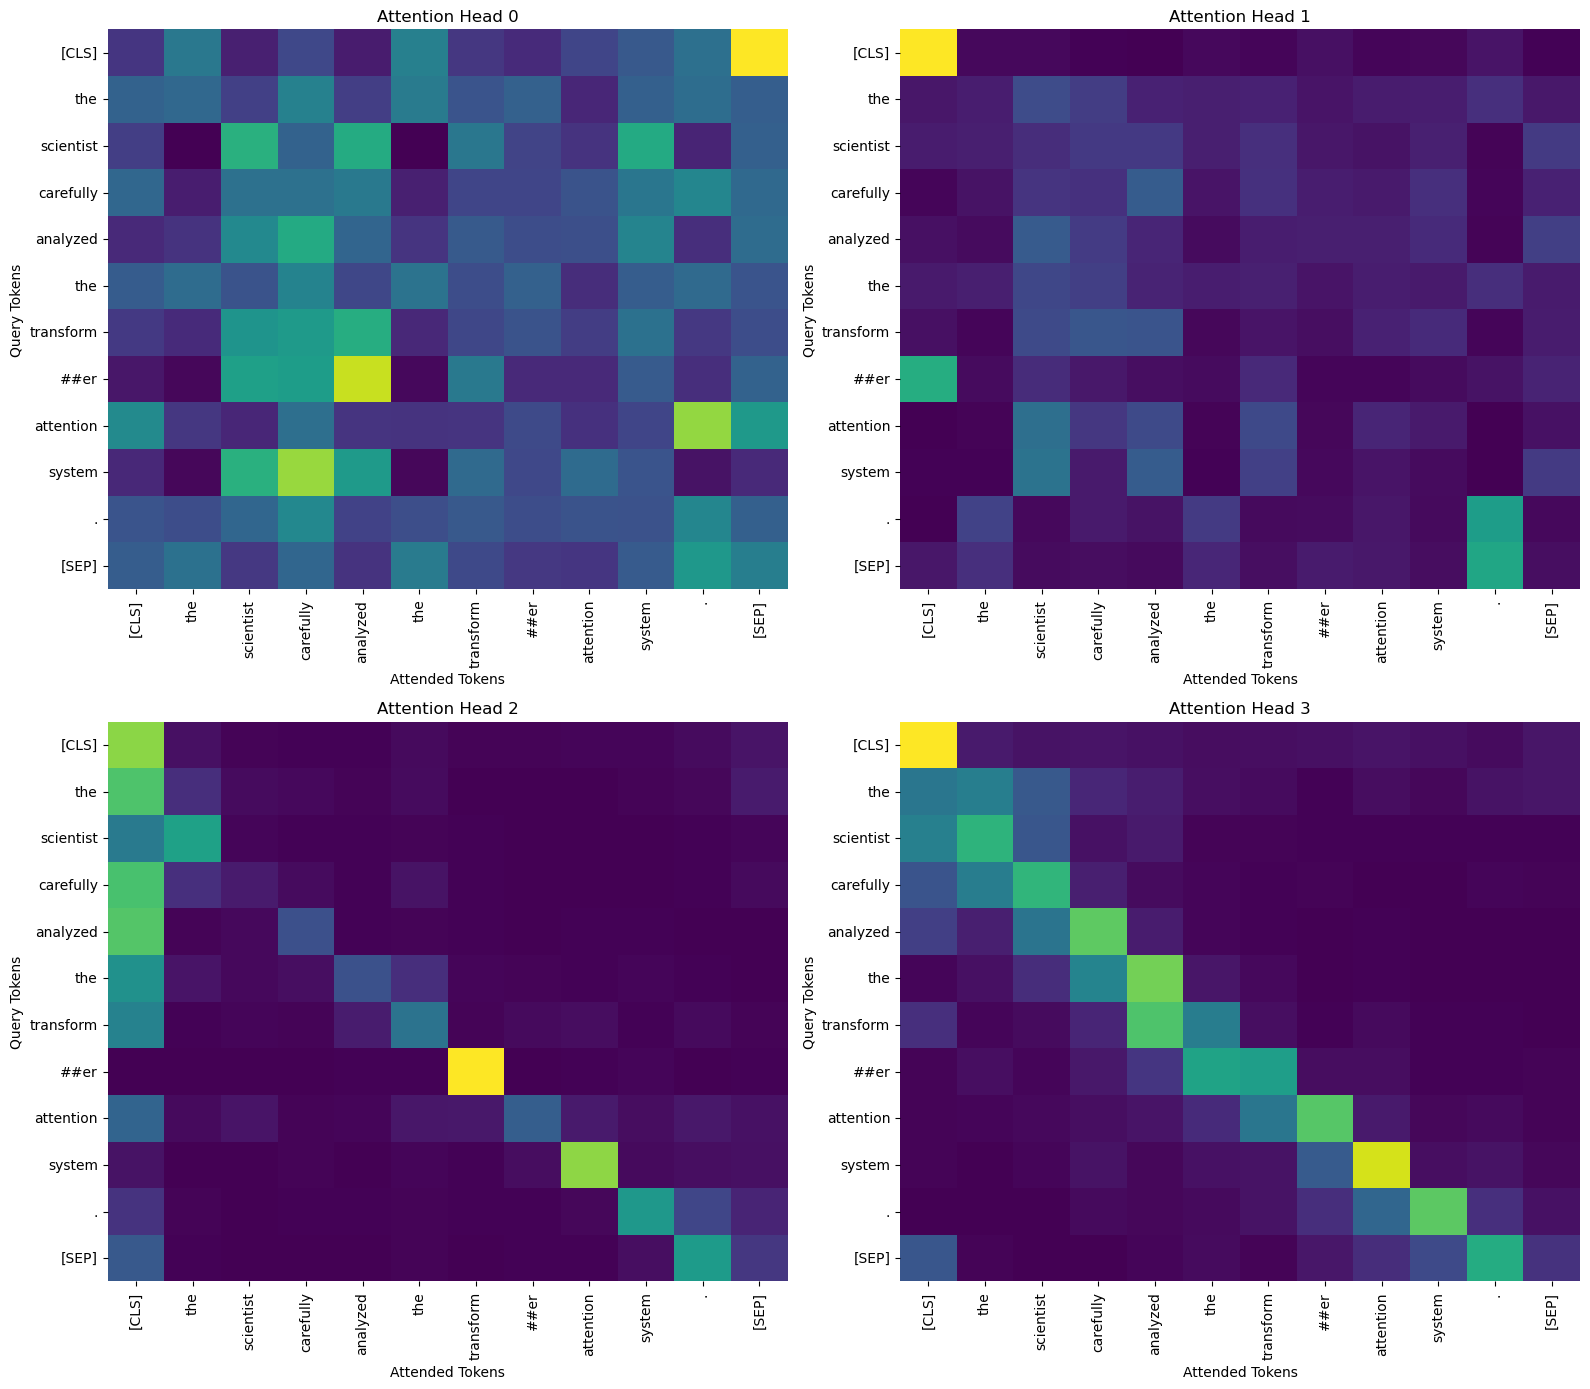

In [7]:

import matplotlib.pyplot as plt
import seaborn as sns

# Visualize first 4 heads

num_visualized_heads = 4

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 14)
)

axes = axes.flatten()

for head_index in range(num_visualized_heads):

    attention_map = (
        layer_attention[head_index]
        .cpu()
        .numpy()
    )

    sns.heatmap(
        attention_map,
        xticklabels=tokens,
        yticklabels=tokens,
        cmap="viridis",
        ax=axes[head_index],
        cbar=False
    )

    axes[head_index].set_title(
        f"Attention Head {head_index}"
    )

    axes[head_index].set_xlabel("Attended Tokens")
    axes[head_index].set_ylabel("Query Tokens")

plt.tight_layout()

plt.show()



============================================================
9. HEAD-WISE TOKEN FOCUS ANALYSIS
============================================================

We now analyze:

    which tokens attract strongest attention

across different heads.

------------------------------------------------------------
IMPORTANT IDEA
------------------------------------------------------------

Different heads may prioritize:

    different semantic regions.

------------------------------------------------------------
QUESTION
------------------------------------------------------------

Which tokens become:

    contextual hubs

for specific heads?




In [8]:

for head_index in range(num_heads):

    print("\n" + "=" * 60)
    print(f"HEAD {head_index} TOKEN FOCUS")
    print("=" * 60)

    head_attention = layer_attention[head_index]

    # Average incoming attention
    token_importance = torch.mean(
        head_attention,
        dim=0
    )

    for token, score in zip(tokens, token_importance):

        print(
            f"{token:15s} "
            f"Importance: {score.item():.4f}"
        )




HEAD 0 TOKEN FOCUS
[CLS]           Importance: 0.0675
the             Importance: 0.0568
scientist       Importance: 0.1008
carefully       Importance: 0.1253
analyzed        Importance: 0.1021
the             Importance: 0.0604
transform       Importance: 0.0758
##er            Importance: 0.0641
attention       Importance: 0.0575
system          Importance: 0.0936
.               Importance: 0.0923
[SEP]           Importance: 0.1038

HEAD 1 TOKEN FOCUS
[CLS]           Importance: 0.1345
the             Importance: 0.0508
scientist       Importance: 0.1461
carefully       Importance: 0.1022
analyzed        Importance: 0.1112
the             Importance: 0.0487
transform       Importance: 0.0812
##er            Importance: 0.0394
attention       Importance: 0.0524
system          Importance: 0.0563
.               Importance: 0.1060
[SEP]           Importance: 0.0711

HEAD 2 TOKEN FOCUS
[CLS]           Importance: 0.4086
the             Importance: 0.0784
scientist       Importance: 0.

#%% [markdown]
# ============================================================
# UNDERSTANDING THE OUTPUT
# ============================================================
#
# This section explains:
#
#     what the printed output actually means
#
# in simple language.
#
# ============================================================
# TOKEN OUTPUT
# ============================================================
#
# Example:
#
#     ['[CLS]', 'the', 'scientist', 'carefully',
#      'analyzed', 'the', 'transform', '##er',
#      'attention', 'system', '.', '[SEP]']
#
# ------------------------------------------------------------
# WHAT HAPPENED HERE?
# ------------------------------------------------------------
#
# The transformer tokenizer converted
# the sentence into:
#
#     smaller processable units called tokens.
#
# ------------------------------------------------------------
# IMPORTANT OBSERVATIONS
# ------------------------------------------------------------
#
# 1. SPECIAL TOKENS
#
#     [CLS]
#         Global contextual aggregation token.
#
#     [SEP]
#         Sequence boundary token.
#
# ------------------------------------------------------------
# 2. SUBWORD TOKENIZATION
# ------------------------------------------------------------
#
# Notice:
#
#     "transformer"
#
# became:
#
#     "transform"
#     "##er"
#
# ------------------------------------------------------------
# WHY?
# ------------------------------------------------------------
#
# Transformers often split rare or complex words
# into:
#
#     smaller reusable subword pieces.
#
# This helps the model handle:
#
#     • rare words
#     • unknown words
#     • morphological structure
#
# ------------------------------------------------------------
# IMPORTANT IDEA
# ------------------------------------------------------------
#
# Transformers do NOT fundamentally process:
#
#     words
#
# They process:
#
#     tokens.
#
# ============================================================
# NUMBER OF TRANSFORMER LAYERS
# ============================================================
#
# Output:
#
#     Number of transformer layers:
#     12
#
# ------------------------------------------------------------
# WHAT DOES THIS MEAN?
# ------------------------------------------------------------
#
# BERT contains:
#
#     12 stacked transformer layers.
#
# Each layer performs:
#
#     • attention interaction
#     • contextual transformation
#     • representation evolution
#
# ------------------------------------------------------------
# IMPORTANT INSIGHT
# ------------------------------------------------------------
#
# Representations continuously evolve:
#
#     layer-by-layer.
#
# Earlier layers:
#
#     local relationships
#
# Later layers:
#
#     abstract contextual meaning
#
# ============================================================
# ATTENTION TENSOR SHAPE
# ============================================================
#
# Output:
#
#     torch.Size([1, 12, 12, 12])
#
# ------------------------------------------------------------
# WHAT DOES THIS MEAN?
# ------------------------------------------------------------
#
# Attention tensor dimensions:
#
#     [batch, heads, tokens, tokens]
#
# ------------------------------------------------------------
# DIMENSION BREAKDOWN
# ------------------------------------------------------------
#
# 1
#
#     One sentence processed.
#
# ------------------------------------------------------------
# 12
#
#     Twelve attention heads.
#
# ------------------------------------------------------------
# 12
#
#     Twelve query tokens.
#
# ------------------------------------------------------------
# 12
#
#     Twelve attended tokens.
#
# ------------------------------------------------------------
# IMPORTANT IDEA
# ------------------------------------------------------------
#
# Every token interacts with:
#
#     every other token.
#
# This creates:
#
#     fully connected interaction topology.
#
# ============================================================
# LAYER ATTENTION SHAPE
# ============================================================
#
# Output:
#
#     torch.Size([12, 12, 12])
#
# ------------------------------------------------------------
# WHAT CHANGED?
# ------------------------------------------------------------
#
# We selected:
#
#     one transformer layer.
#
# Therefore:
#
#     batch dimension disappeared.
#
# Remaining dimensions:
#
#     [heads, query_tokens, attended_tokens]
#
# ------------------------------------------------------------
# INTERPRETATION
# ------------------------------------------------------------
#
# Each head contains:
#
#     its own interaction matrix.
#
# ============================================================
# HEAD SPECIALIZATION SUMMARY
# ============================================================
#
# Example:
#
#     HEAD 0
#     Average Attention : 0.0833
#     Maximum Attention : 0.2626
#
# ------------------------------------------------------------
# WHAT IS "AVERAGE ATTENTION"?
# ------------------------------------------------------------
#
# Attention values form:
#
#     probability distributions.
#
# Since:
#
#     12 tokens exist
#
# uniform attention becomes:
#



#
# Therefore:
#
#     average attention ≈ 0.0833
#
# is expected.
#
# ------------------------------------------------------------
# IMPORTANT INSIGHT
# ------------------------------------------------------------
#
# This means:
#
#     if attention were perfectly uniform,
#
# every token would receive:
#
#     equal importance.
#
# ============================================================
# WHAT IS "MAXIMUM ATTENTION"?
# ============================================================
#
# Example:
#
#     Maximum Attention : 0.9556
#
# ------------------------------------------------------------
# INTERPRETATION
# ------------------------------------------------------------
#
# One token attended VERY strongly
# to another token.
#
# ------------------------------------------------------------
# IMPORTANT IDEA
# ------------------------------------------------------------
#
# High maximum attention suggests:
#
#     strong contextual focus.
#
# Some heads become:
#
#     highly selective.
#
# Others remain:
#
#     more distributed.
#
# ============================================================
# TOKEN FOCUS OUTPUT
# ============================================================
#
# Example:
#
#     analyzed        Importance: 0.1943
#
# ------------------------------------------------------------
# WHAT DOES THIS MEAN?
# ------------------------------------------------------------
#
# Many tokens strongly attended to:
#
#     "analyzed"
#
# Therefore:
#
#     "analyzed" became an important
#     contextual interaction hub.
#
# ------------------------------------------------------------
# IMPORTANT INSIGHT
# ------------------------------------------------------------
#
# Transformer attention dynamically identifies:
#
#     contextually important tokens.
#
# ============================================================
# WHY DOES [CLS] OFTEN HAVE HIGH IMPORTANCE?
# ============================================================
#
# Example:
#
#     [CLS] Importance: 0.4086
#
# ------------------------------------------------------------
# INTERPRETATION
# ------------------------------------------------------------
#
# [CLS] acts like:
#
#     global context collector.
#
# Many tokens route information toward:
#
#     [CLS]
#
# because it accumulates:
#
#     sentence-level information.
#
# ------------------------------------------------------------
# IMPORTANT IDEA
# ------------------------------------------------------------
#
# [CLS] often behaves like:
#
#     a global semantic memory node.
#
# ============================================================
# WHY DO DIFFERENT HEADS SHOW DIFFERENT BEHAVIOR?
# ============================================================
#
# Notice:
#
#     different heads prioritize
#     different tokens.
#
# Example:
#
#     Head 2 strongly focuses on [CLS]
#
# while:
#
#     Head 6 strongly focuses on "analyzed"
#
# ------------------------------------------------------------
# INTERPRETATION
# ------------------------------------------------------------
#
# Different heads specialize in:
#
#     different contextual interaction patterns.
#
# ------------------------------------------------------------
# IMPORTANT INSIGHT
# ------------------------------------------------------------
#
# Multi-head attention creates:
#
#     distributed relational analysis.
#
# ============================================================
# QT WARNING
# ============================================================
#
# Output:
#
#     qt.qpa.plugin:
#     Could not find the Qt platform plugin "wayland"
#
# ------------------------------------------------------------
# SHOULD YOU WORRY?
# ------------------------------------------------------------
#
# No.
#
# This is usually:
#
#     a graphical backend warning
#
# from the plotting environment.
#
# It does NOT affect:
#
#     transformer computation.
#
# ------------------------------------------------------------
# IMPORTANT NOTE
# ------------------------------------------------------------
#
# The model and attention analysis
# still executed correctly.
#
# ============================================================
# MOST IMPORTANT TAKEAWAY
# ============================================================
#
# This output reveals something profound:
#
# Transformers are NOT processing:
#
#     isolated words.
#
# Instead they construct:
#
#     dynamic interaction systems
#
# where:
#
#     • tokens influence each other
#     • attention routes information
#     • different heads specialize
#     • contextual meaning evolves
#
# inside:
#
#     high-dimensional representation space.
#
# ============================================================
# DEEP QUESTION
# ============================================================
#
# If meaning emerges through:
#
#     dynamic interaction topology,
#
# then could intelligence itself emerge through:
#
#     evolving relational structure?
#

============================================================
10. INTERACTION TOPOLOGY COMPARISON
============================================================

Different heads may exhibit:

    different interaction topology.

------------------------------------------------------------
EXAMPLES
------------------------------------------------------------

Some heads may:

    • focus locally
    • track long-range dependencies
    • emphasize punctuation
    • route semantic information

------------------------------------------------------------
IMPORTANT INSIGHT
------------------------------------------------------------

Multi-head attention creates:

    distributed contextual processing.

------------------------------------------------------------
VERY IMPORTANT IDEA
------------------------------------------------------------

Transformers may internally construct:

    multiple simultaneous relational worlds.




============================================================
11. INTERPRETATION
============================================================

OBSERVATION ANALYSIS
--------------------

Compare attention heads carefully.

Possible observations:

    • some heads attend broadly
    • some heads focus narrowly
    • some heads emphasize semantic tokens
    • some heads track structural organization

------------------------------------------------------------
IMPORTANT REALIZATION
------------------------------------------------------------

Transformers do NOT process context
through one unified mechanism.

Instead:

    many specialized subsystems operate in parallel.

------------------------------------------------------------
HEAD SPECIALIZATION
------------------------------------------------------------

Attention heads behave like:

    distributed relational analyzers.

------------------------------------------------------------
VERY IMPORTANT INSIGHT
------------------------------------------------------------

Contextual understanding may emerge through:

    multiple interacting relational perspectives.

------------------------------------------------------------
DEEP QUESTION
------------------------------------------------------------

Could cognition itself require:

    distributed specialization systems?




============================================================
12. FAILURE CASES
============================================================

REAL SYSTEMS ARE IMPERFECT
--------------------------

Head analysis possesses limitations.

------------------------------------------------------------
LIMITATION 1 — SPECIALIZATION IS NOT ABSOLUTE
------------------------------------------------------------

Attention heads are NOT perfectly isolated.

Multiple heads may:

    overlap in behavior.

------------------------------------------------------------
LIMITATION 2 — ATTENTION ≠ FULL REASONING
------------------------------------------------------------

Attention maps reveal:

    interaction weighting

not complete reasoning structure.

------------------------------------------------------------
LIMITATION 3 — CONTEXT DEPENDENCE
------------------------------------------------------------

Head behavior changes dynamically
across different sentences.

------------------------------------------------------------
LIMITATION 4 — VISUALIZATION SIMPLIFICATION
------------------------------------------------------------

Heatmaps simplify:

    extremely high-dimensional interaction dynamics.

------------------------------------------------------------
THINK CRITICALLY
------------------------------------------------------------

Are transformer heads truly specialized,

or are we observing:

    emergent statistical behavior?




============================================================
13. SCIENTIFIC INSIGHT
============================================================

MOST IMPORTANT INSIGHT
----------------------

Transformers process information through:

    distributed relational specialization.

------------------------------------------------------------
MULTI-HEAD ATTENTION ENABLES
------------------------------------------------------------

    • parallel contextual analysis
    • distributed semantic routing
    • hierarchical interaction modeling
    • adaptive representation evolution

------------------------------------------------------------
FOUNDATIONAL REALIZATION
------------------------------------------------------------

Intelligence may require:

    multiple simultaneous relational viewpoints.

------------------------------------------------------------
IMPORTANT TRANSITION
------------------------------------------------------------

We are no longer studying:

    simple attention routing

but:

    distributed contextual cognition systems.

------------------------------------------------------------
LOOK AHEAD
------------------------------------------------------------

Next steps investigate:

    • contextual representation shift
    • layerwise representation evolution
    • semantic reinterpretation
    • latent representation dynamics

We are progressively uncovering:

    AI as distributed representation cognition.




============================================================
14. EXPLORATION EXERCISES
============================================================

EXPLORATION 1
-------------

Compare:

    different transformer layers.

Do deeper layers show:

    more abstract specialization?

------------------------------------------------------------
EXPLORATION 2
-------------

Try ambiguous sentences:

    "The bank approved the loan."
    "The river reached the bank."

Do heads specialize differently?

------------------------------------------------------------
EXPLORATION 3
-------------

Compare:

    short vs long sentences.

Does specialization complexity increase?

------------------------------------------------------------
EXPLORATION 4
-------------

Replace BERT with:

    • RoBERTa
    • GPT-2
    • DistilBERT

Does head specialization structure change?

------------------------------------------------------------
EXPLORATION 5
-------------

Compute:

    similarity between attention heads.

Are some heads redundant?

------------------------------------------------------------
FINAL QUESTION
------------------------------------------------------------

If intelligence emerges through:

    multiple relational perspectives,

then could cognition fundamentally require:

    distributed specialization systems?

============================================================

NB:

# ============================================================
# WHAT IS AN ATTENTION HEAD?
# ============================================================
#
# SIMPLE DEFINITION
# -----------------
#
# An attention head is:
#
#     an independent attention mechanism
#
# inside a transformer.
#
# Each head learns:
#
#     its own way of analyzing relationships
#     between tokens.
#
# ------------------------------------------------------------
# CORE IDEA
# ------------------------------------------------------------
#
# Instead of using:
#
#     one single attention pattern,
#
# transformers use:
#
#     many attention heads in parallel.
#
# This allows the model to observe:
#
#     multiple relational perspectives
#
# simultaneously.
#
# ============================================================
# SIMPLE HUMAN ANALOGY
# ============================================================
#
# Imagine several people reading the same sentence.
#
# One person focuses on:
#
#     grammar
#
# Another focuses on:
#
#     meaning
#
# Another focuses on:
#
#     important entities
#
# Another focuses on:
#
#     long-range relationships
#
# ------------------------------------------------------------
# IMPORTANT IDEA
# ------------------------------------------------------------
#
# Each person represents:
#
#     one attention head.
#
# Together:
#
#     they build richer contextual understanding.
#
# ============================================================
# SIMPLE LANGUAGE EXAMPLE
# ============================================================
#
# Sentence:
#
#     "The scientist analyzed the data carefully."
#
# ------------------------------------------------------------
# HEAD 1 MAY FOCUS ON:
# ------------------------------------------------------------
#
#     analyzed ↔ scientist
#
# learning:
#
#     subject-action relationship
#
# ------------------------------------------------------------
# HEAD 2 MAY FOCUS ON:
# ------------------------------------------------------------
#
#     analyzed ↔ data
#
# learning:
#
#     action-object relationship
#
# ------------------------------------------------------------
# HEAD 3 MAY FOCUS ON:
# ------------------------------------------------------------
#
#     carefully ↔ analyzed
#
# learning:
#
#     modifier relationship
#
# ------------------------------------------------------------
# IMPORTANT INSIGHT
# ------------------------------------------------------------
#
# Different heads may specialize in:
#
#     different interaction structures.
#
# ============================================================
# MATHEMATICAL VIEW
# ============================================================
#
# Each head has:
#
#     its own query, key, and value matrices.
#
# Example:
#
#     Head 1:
#
#         Q₁, K₁, V₁
#
#     Head 2:
#
#         Q₂, K₂, V₂
#
# Therefore:
#
#     each head computes different attention patterns.
#
# ============================================================
# SINGLE HEAD FORMULATION
# ============================================================
#



#
# ------------------------------------------------------------
# INTERPRETATION
# ------------------------------------------------------------
#
# Each head creates:
#
#     its own interaction topology.
#
# ============================================================
# MULTI-HEAD COMBINATION
# ============================================================
#
# Transformer combines all heads:
#



#
# ------------------------------------------------------------
# IMPORTANT INSIGHT
# ------------------------------------------------------------
#
# The final representation contains:
#
#     information aggregated from
#     multiple relational perspectives.
#
# ============================================================
# VERY IMPORTANT CONCEPTUAL INSIGHT
# ============================================================
#
# A transformer head is NOT:
#
#     a memory slot
#
# or:
#
#     a neuron group.
#
# Instead:
#
# a head is:
#
#     an independent contextual interaction system.
#
# ============================================================
# DEEP QUESTION
# ============================================================
#
# If intelligence requires understanding:
#
#     many relationships simultaneously,
#
# then could multi-head attention represent:
#
#     distributed relational cognition?
#